In [1]:
import numpy as np
import mne

In [2]:
path = 'C:/Users/mvmigem/Documents/data/project_2/foto_diode_test_project_2.bdf'
raw = mne.io.read_raw_bdf(path, preload = True)
ergo = raw.copy().pick("Erg1")

Extracting EDF parameters from C:\Users\mvmigem\Documents\data\project_2\foto_diode_test_project_2.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 48127  =      0.000 ...    93.998 secs...


Using qt as 2D backend.
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
140 events found on stim channel Status
Event IDs: [   11    13    22    24    31    33    42    44    99 65789]


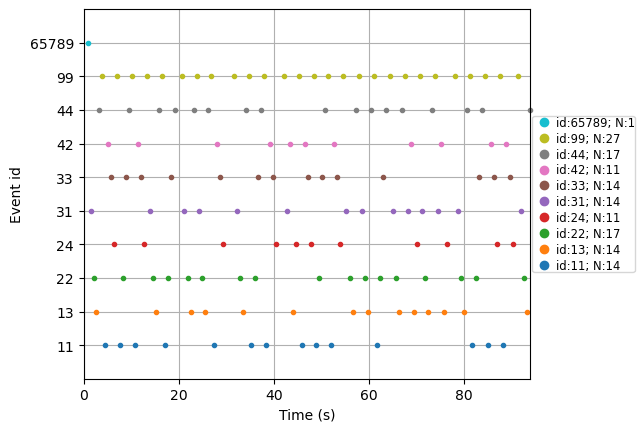

Channels marked as bad:
none


In [3]:
ergo.plot()
events = mne.find_events(raw,shortest_event=1)
fig = mne.viz.plot_events(events, 
                          sfreq = ergo.info['sfreq'],)

In [13]:
ergo.plot(picks="Erg1",events=events)

In [ ]:
er_data = ergo.get_data()[0]
photodiode_norm = (er_data - np.mean(er_data)) / np.std(er_data)


Not setting metadata
11 matching events found
Setting baseline interval to [-0.099609375, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Need more than one channel to make topography for eeg. Disabling interactivity.


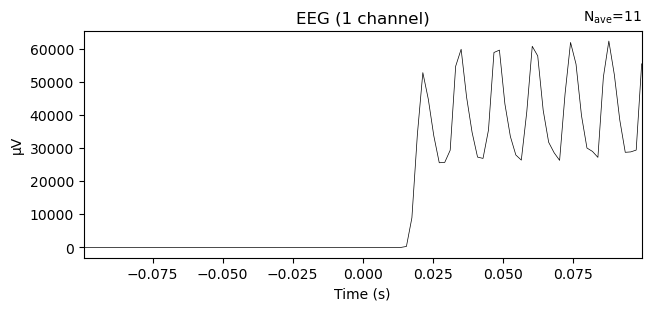

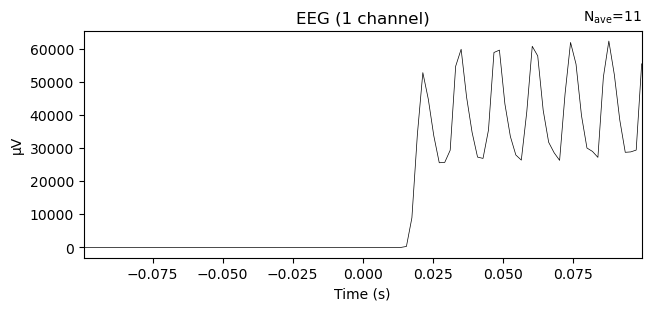

In [24]:
event_id = {
        'pos2':22,'pos2':24 
    }
# Epoch data around stim onset
epochs = mne.Epochs(ergo, events, event_id = event_id,
    tmin = -0.1, tmax = 0.1,)

evoked = epochs['pos2'].average()
evoked.plot()


In [93]:
ev_data = evoked.get_data()[0]
times = evoked.times
i = 1
continu = True
while ev_data[i] < (ev_data[i-1] + .00001) and (i < len(ev_data) - 1):
    i += 1

time = times[i]

In [94]:
time


np.float64(0.015625)